Script Overview
1. Filters docs to go from 2022-2024
2. Checks for docs that have uncertainty 
3. Plots the distribution of uncertainty terms per doc 
4. Plots unique words per doc
5. Plots type of term and frequency
6. Looks at context around uncertainty terms (single words) found
7. Implementation of Bigrams

In [ ]:
# import packages 
import spacy 
import os
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fbad67f42b0>>
Traceback (most recent call last):
  File "/home/iwag@cbsp.nl/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


1. Filters docs to go from 2022-2024

In [4]:
import os
import re
from datetime import datetime
import shutil


def filter_articles_ABS(directory, output_directory):
    filtered_articles = []

    for file in os.listdir(directory):
        if file.endswith("txt"):
            article_path = os.path.join(directory, file)

            with open(article_path, "r") as f:
                text = f.readlines()

                date = text[1].strip()

                try:
                    a_date = datetime.strptime(date, "%Y-%m-%d")
                    if a_date >= datetime(2022,1,1):
                        filtered_articles.append(article_path)
                        output_path = os.path.join(output_directory, file)
                        shutil.copy(article_path, output_path)

                except ValueError:
                    print(f"Skipping file as file is earlier than 2022")

    return(filtered_articles)

directory =  "scraped"
output_directory = "filtered_a"


In [ ]:
filter_articles_ABS(directory, output_directory)


2. Checks for docs that have uncertainty

In [2]:
import os
import spacy
from nltk.util import ngrams
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



nlp = spacy.load("en_core_web_sm")



uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])


# tokenization fnc
excluded_tokens = set()
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)

    doc = nlp(text)
    return doc
   

# uncertainty fnc
def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms


# Directory with files
directory = "filtered_a"  


doc_u_counts = []
filenames = []

total_u_counts = 0

for file in os.listdir(directory):
    file_path = os.path.join(directory, file)
    doc = tokenize_text(file_path)

    found_terms = find_uncertainty_terms(doc)
    if found_terms:
        total_u_counts += 1

        doc_u_counts.append(len(found_terms))
        filenames.append(file)
        


In [2]:
# converting it to a dataframe
df = pd.DataFrame(doc_u_counts, index = filenames, columns = ["Uncertainty"] )
# check no of docs
len(df)
# check no of uncertainty terms
df.sum()

Uncertainty    1763
dtype: int64

In [3]:
# checking the max number of docs 
df["Uncertainty"].sort_values(ascending = False)

measuring-australias-excess-mortality-during-covid-19-pandemic-until-december-2023.txt         114
characteristics-previous-australian-defence-force-personnel.txt                                111
measuring-australias-excess-mortality-during-covid-19-pandemic-until-first-quarter-2023.txt    109
measuring-australias-excess-mortality-during-covid-19-pandemic-until-august-2023.txt            92
measuring-australias-excess-mortality-during-covid-19-pandemic.txt                              78
                                                                                              ... 
intermediate-use-and-output-ratios-australian-economy.txt                                        1
insights-hours-worked-october-2022.txt                                                           1
insights-hours-worked-december-2021.txt                                                          1
major-rebenchmarking-labour-force-estimates.txt                                                  1
insights-h

3. Plots the distribution of uncertainty terms per doc 

In [ ]:
# plot a histogram
plt.figure()
sns.displot(df["Uncertainty"], bins = 20)
plt.xlabel("Number of uncertainty terms in one document")
plt.ylabel("Number of documents")


Text(0, 0.5, 'Number of documents')

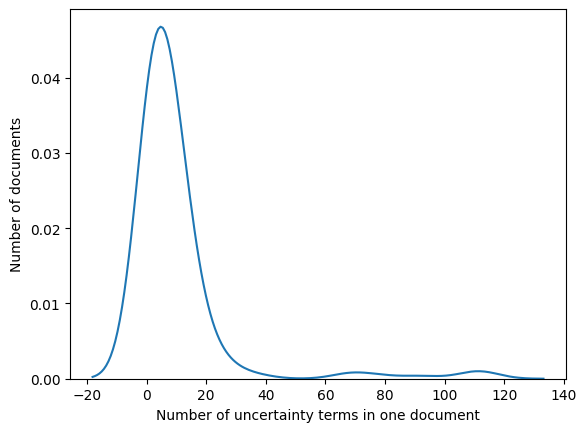

In [ ]:
# trying a KDE plot
sns.kdeplot(df["Uncertainty"], common_norm= False)
plt.xlabel("Number of uncertainty terms in one document")
plt.ylabel("Number of documents")

<Axes: xlabel='Uncertainty'>

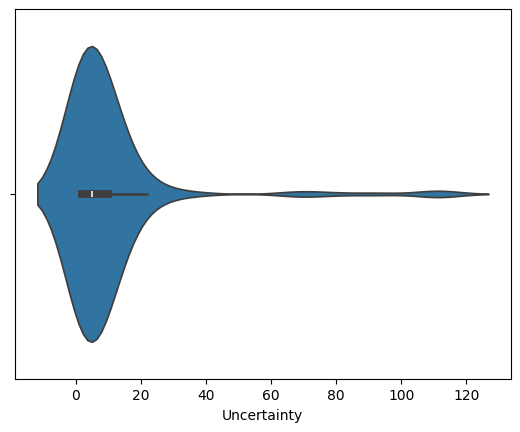

In [ ]:
# trying a violin plot
sns.violinplot(x = df["Uncertainty"])

4. Plots unique words per doc

In [3]:
import os
import pandas as pd



uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])



def tokenize(file):
    with open(file, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)
    doc = nlp(text)
    return doc
    


def find_uncertainty_term(doc_tok):
    found_terms = set()
    found_terms.update([w.text.lower() for w in doc if w.text.lower() in uncertainty_terms])
    return found_terms


    
doc_u_counts = []
filenames = []
unique_terms = []
total_uc = 0
for file in os.listdir("filtered_a"):
    filepath = os.path.join("filtered_a", file)
    doc = tokenize(filepath)
    found_terms = find_uncertainty_term(doc)

    if found_terms:
        total_uc += 1

        doc_u_counts.append(len(found_terms))
        filenames.append(file)
        unique_terms.append(found_terms)


df = pd.DataFrame(doc_u_counts, index = filenames, columns = ["Unique Uncertainty Terms"] )


In [4]:
counts = df["Unique Uncertainty Terms"].value_counts().sort_index()
counts_sorted = counts.sort_index(ascending = False)
counts_sorted

Unique Uncertainty Terms
11     2
10     2
8      2
7      6
6     11
5     31
4     21
3     19
2     38
1     47
Name: count, dtype: int64

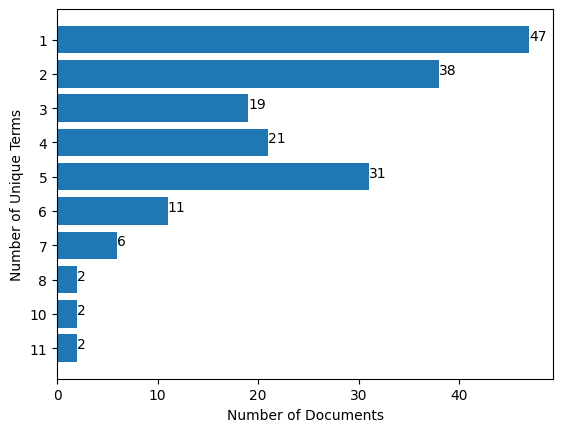

In [5]:
# plot unique counts
plt.figure()
plt.barh(y = range(len(counts_sorted.index)), width = counts_sorted.values)
plt.yticks(ticks=range(len(counts_sorted)), labels = counts_sorted.index)
for idx, value in enumerate(counts_sorted.values):
    plt.text(value, idx, f"{value}")
plt.ylabel("Number of Unique Terms")
plt.xlabel("Number of Documents")
plt.savefig("statcan_unique_dist.png")
plt.show("Unique Term Uncertainty Count")

5. Plots type of term and frequency

In [88]:
# for this we will use Counter
import os
import pandas as pd
import spacy
from collections import Counter


uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","often","inconclusive",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])

def tokenize(file):
    with open(file, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)
    doc = nlp(text)
    return doc
    


def find_uncertainty_term(doc_tok):
    found_terms = []
    for w in doc_tok:
        if w.text.lower() in uncertainty_terms:
            found_terms.append(w.text.lower())
    return found_terms


    
doc_u_counts = Counter()

filenames = []
total_uc = 0
for file in os.listdir("filtered_a"):
    filepath = os.path.join("filtered_a", file)
    doc = tokenize(filepath)
    terms = find_uncertainty_term(doc)
    doc_u_counts.update(terms)
    filenames.append(file)



In [90]:
y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())
df = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))
df_sorted = df.sort_values("freq", ascending= False)

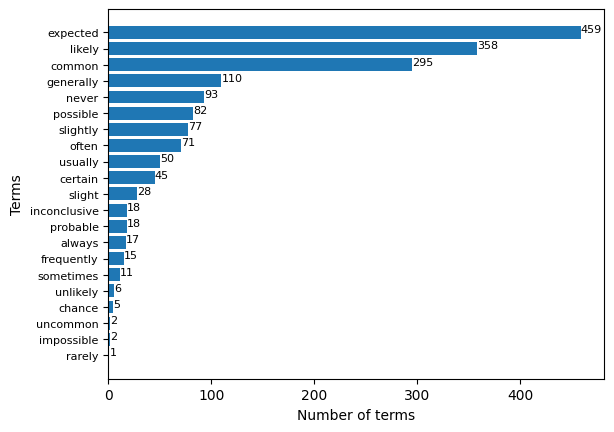

In [ ]:
# plot type and frequency of uncertainty terms
def addlabels(df_sorted):
    for i in range(len(df_sorted)):
        plt.text(df_sorted.iloc[i]["freq"] + 0.2,i, str(df_sorted.iloc[i]["freq"]), fontsize = 8)


df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
plt.barh(df_sorted["words"] ,df_sorted["freq"])
addlabels(df_sorted)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 8)
plt.show()

6. Looks at context around uncertainty terms (single words) found

In [ ]:
import os
import spacy
from nltk.util import ngrams


nlp = spacy.load("en_core_web_sm")

uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])


# tokenization fnc
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[7:]
        text = "".join(lines)


    doc = nlp(text)
    return doc

# uncertainty fnc
def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [word for word in doc_tokens if word in uncertainty_terms]
    return found_terms

# term context fnc
# gives a window of 15 terms before 15 terms after
def find_word_context(doc_tokens, word, window=15):
    term_contexts = []
    
    for i, token in enumerate(doc_tokens):
        if token.text.lower() == word.lower():
            start = max(0, i - window)
            end = min(len(doc_tokens), i + window )
            term_contexts.append(doc_tokens[start:end])

    return term_contexts

# Directory with files
directory = "filtered_a"  

# Directory where files with word context will be done
output_directory = "term_contexts"

output_file_path = os.path.join(output_directory, "rarely.txt")


with open(output_file_path, "w") as out_file:
    for file in os.listdir(directory):
        file_path = os.path.join(directory, file)
        doc = tokenize_text(file_path)
        
        # change the word to the word you want to know the context for
        word_contexts = find_word_context(doc, "rarely")
        
        if word_contexts:
            out_file.write(f"Title : {file}\n")

            for ctx in word_contexts:
                out_file.write("Context:" + " ".join([token.text for token in ctx]) + "\n")
            out_file.write("\n")


7. Implementation of Bigrams

In [3]:
import spacy 
from spacy.matcher import PhraseMatcher

In [16]:
import os

nlp = spacy.load("en_core_web_sm")

# create bigrams -> turn into docs so phrase matcher can work with it 
matcher = PhraseMatcher(nlp.vocab)

bigrams = ["almost always", "almost certain", "almost impossible", "almost never", 
           "high chance", "low chance", "very likely","slightly likely", "very often", "very unlikely", "not always"]
patterns = [nlp(bigram) for bigram in bigrams]

matcher.add("BIGRAMS", patterns)

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)
        doc = nlp(text)
        return(doc)

for file in os.listdir("filtered_a"):
    file_path = os.path.join("filtered_a", file)
    doc = tokenize_text(file_path)
    matches = matcher(doc)   

    for match_id, start, end in matches:
        matched_span = doc[start:end]
        print(f"Matched bigram: '{matched_span.text}' in file {file}")


Matched bigram: 'not always' in file technical-note-impact-using-multiple-sources-deriving-indigenous-status-deaths-2023-changes-victoria-and-coroner-referred-deaths.txt
Matched bigram: 'not always' in file development-new-experimental-monthly-household-spending-indicator.txt
Matched bigram: 'very likely' in file restraint-clauses-australia-2023.txt
Matched bigram: 'very likely' in file restraint-clauses-australia-2023.txt
Matched bigram: 'very unlikely' in file restraint-clauses-australia-2023.txt
Matched bigram: 'very unlikely' in file restraint-clauses-australia-2023.txt
Matched bigram: 'not always' in file anzsco-maintenance-strategy-core-components.txt
Matched bigram: 'not always' in file sexual-assault-perpetrators.txt


In [ ]:
import os
import spacy
from collections import Counter
nlp = spacy.load("en_core_web_sm")

# create bigrams -> turn into docs so phrase matcher can work with it 
matcher = PhraseMatcher(nlp.vocab)

bigrams = ["almost always", "almost certain", "almost impossible", "almost never", 
           "high chance", "low chance", "very likely", "very often", "very unlikely", "not always"]

patterns = [nlp(bigram) for bigram in bigrams]

matcher.add("BIGRAMS", patterns)

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)
        doc = nlp(text)
        return(doc)


bigram_count = Counter()
for file in os.listdir("filtered_a"):
    file_path = os.path.join("filtered_a", file)
    doc = tokenize_text(file_path)
    matches = matcher(doc)   

    for match_id, start, end in matches:
        matched_span = doc[start:end]
        bigram_count[matched_span.text] += 1

b_counts = bigram_count.most_common()

(0.0, 5.0)

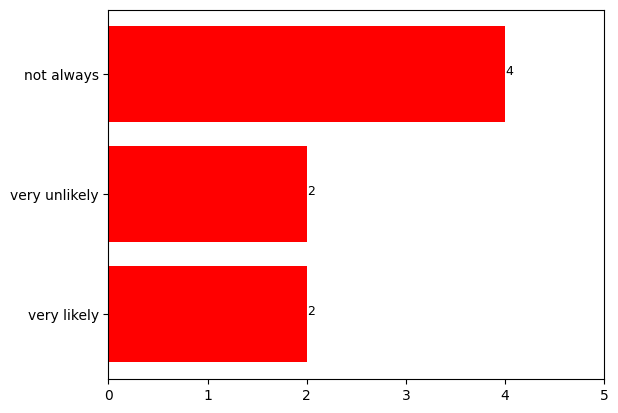

In [17]:
import matplotlib.pyplot as plt
b_counts.sort(key = lambda x:x[1], reverse = False)  
bigrams , counts = zip(*b_counts)
plt.figure()
bars = plt.barh(bigrams, counts, color = "red")
for bar in bars:
    x_value = bar.get_width()
    plt.text(x_value, bar.get_y() + bar.get_height()/2 , str(x_value), fontsize = 9)

plt.xlim(0,5)